In [1]:
from matplotlib import pyplot as plt
from scipy.spatial.distance import cdist
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

import torch
import numpy as np
from copy import deepcopy
from functools import reduce

from torch import nn
import pickle as pkl
from umap import UMAP

from model import DNN
from run_sim import Config, run_sim, create_data, train_model
from utils import cosine_similarity, get_r_2, vector_angle, flatten_list
from tqdm import tqdm
from utils import alignment_score, calc_PR, calc_NC1
import matplotlib as mpl
from functools import reduce



In [2]:
def calc_h_var(G, D, N, L, sig_X):
    return G**(2*L)*(2*D*sig_X)/(D+N)

In [3]:
C = Config()

C.G = 0.8
C.sig_h_2 = 1e-5
# C.gpu_id=1
# C.seed = 1
C.linear_net = True
C.split_actions = True
# C.allow_backwards = True
C.learning_rate = 0.01
C.L=5
C.print_progress = True
C.length_corridors = [20]*1
# C.input_size = 100
C.max_move = 10
C.hidden_size = sum(C.length_corridors)+2*C.max_move+1 + 1
C.num_epochs *= 10
C.algo_name = 'SGD'
C.loss_fn = nn.CrossEntropyLoss()
C.bias = False
C.egocentric_movement = True
C.lambda_reg = 0
# C.whiten_data = True
# C.fixed_output = False
# C.split_actions = False
# C.allow_backwards = True

# C.min_move = 2
# C.one_hot_actions = True
# C.one_hot_inputs = False

In [ ]:


data_dict_l = []
for i in range(3):
    device = torch.device(f"cuda:{C.gpu_id}" if torch.cuda.is_available() and use_gpu else "cpu")
    torch.manual_seed(C.seed)
    np.random.seed(C.seed)
    X, y, corridor, loc_X, loc_y, action_taken, dim_l, input_size, output_size, n_actions = create_data(C)

    if i > 0:
        cond = abs(action_taken) <= 1
        X = X[cond]
        y = y[cond]
        loc_y = loc_y[cond]
        corridor = corridor[cond]
        loc_X = loc_X[cond]
        action_taken = action_taken[cond]

    X = torch.tensor(X, dtype=torch.float32).to(device)
    y = torch.tensor(y, dtype=torch.float32).to(device)

    if C.sig_h_2 and C.print_progress:
        C.G = (C.sig_h_2*(X.shape[1]+C.hidden_size)/(2*X.shape[1]*X.var()))**(1/(2*C.L))
        print(f'Changed G to {C.G} to get sig_h_2 = {C.sig_h_2}')
    # Create model
    model = DNN(input_size + n_actions, C.hidden_size, output_size, C.L, C.fixed_output, C.linear_net, C.G, C.bias).to(device)
    if i == 2:
        model.load_state_dict(data_dict_l[0]['model_state'])
        for param, param_i in zip(model.parameters(), data_dict_l[0]['initial_weights'].values()):
            noise = torch.randn_like(param) * (param.std()*0.1)
            # param.data.add_(noise)
            param.data *= param_i.std()/param.std()
    initial_weights = deepcopy(model.state_dict())

    loss_l, accuracy_l, hidden_l = train_model(C, X, y, model)
    # Testing
    with torch.no_grad():
        outputs, hidden_states = model(X)
    # print(criterion(outputs, y).item()/y_var)
    print(calc_h_var(C.G, X.shape[1], C.hidden_size, C.L, X.var().cpu().numpy()))
    hidden = hidden_states[-1].detach().cpu().numpy()
    X_dist = torch.cdist(X, X).cpu().numpy()
    y_dist = torch.cdist(y, y).cpu().numpy()
    hidden_dist = torch.cdist(hidden_states[-1].detach(), hidden_states[-1].detach()).cpu().numpy()
    stay_inds = np.where(action_taken == 0)[0]
    loc_y_corridor = loc_y + (corridor * max(loc_y + 1))
    n_corridors = len(C.length_corridors)

    X_np = X.cpu().numpy()  # Convert to numpy array if X is a torch tensor
    y_np = y.cpu().numpy()  # Convert to numpy array if y is a torch tensor
    h_np = hidden  # Convert to numpy array if hidden is a torch tensor

    data_dict = {
        'X': X,
        'y': y,
        'corridor': corridor,
        'loc_X': loc_X.squeeze(),
        'loc_y': loc_y.squeeze(),
        'action_taken': action_taken,
        'hidden_states': hidden_states,
        'loss_l': loss_l,
        'accuracy_l': accuracy_l,
        'outputs': outputs.cpu().numpy(),
        'hidden_l': hidden_l,
        'model_state': deepcopy(model.state_dict()),
        'initial_weights': initial_weights,
        'X_dist': X_dist,
        'y_dist': y_dist,
        'hidden_dist': hidden_dist,
        'stay_inds': stay_inds,
        'loc_y_corridor': loc_y_corridor,
        'n_corridors': n_corridors,
        'X_np': X_np,
        'y_np': y_np,
        'h_np': h_np,
        'C': C
    }

    data_dict_l.append(data_dict)

with open('data_dict_l.pkl', 'wb') as f:
    pkl.dump(data_dict_l, f)

In [4]:
with open('data_dict_l.pkl', 'rb') as f:
    data_dict_l = pkl.load(f)

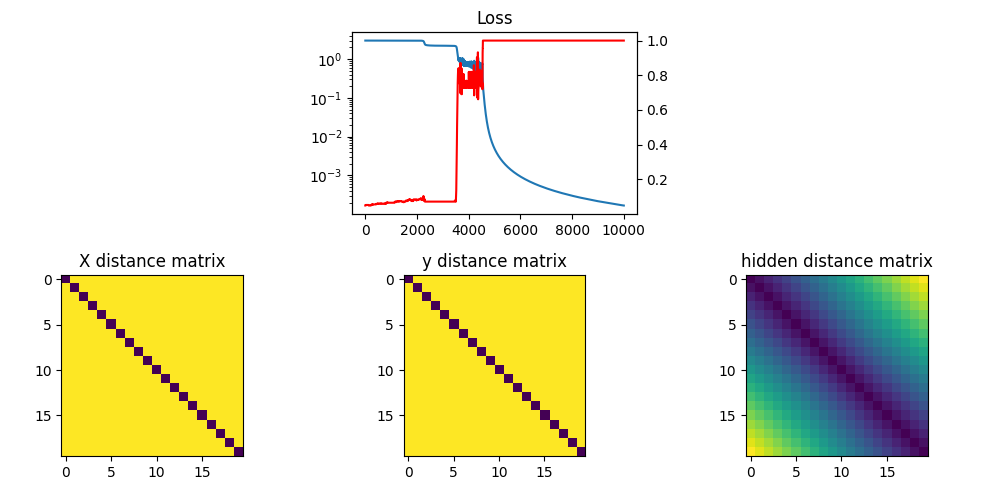

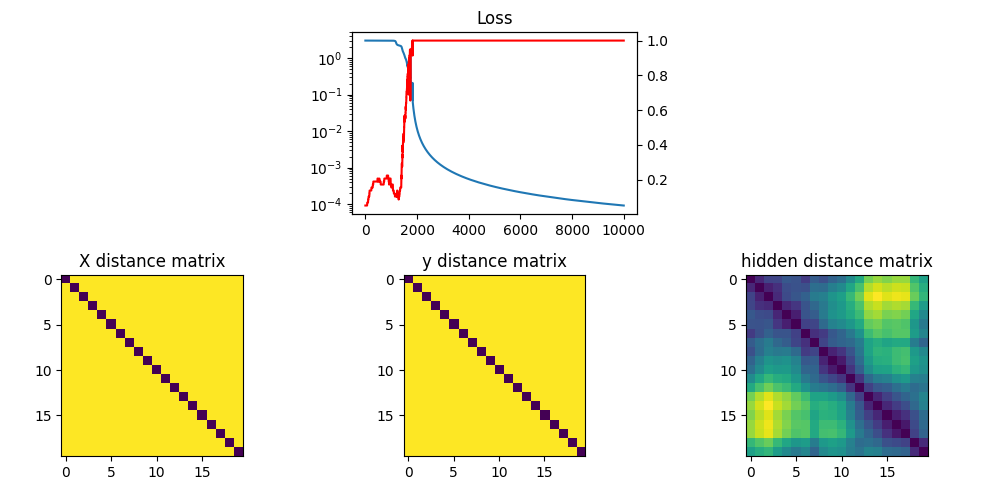

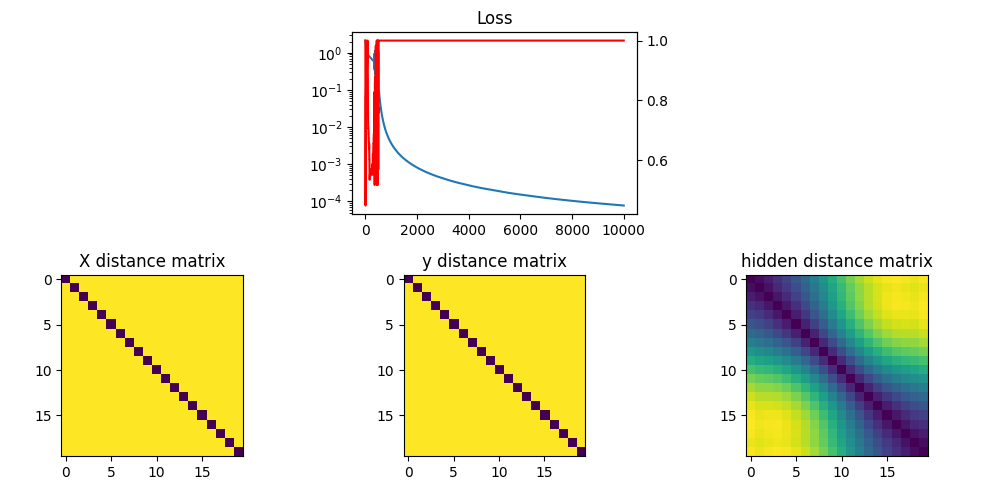

In [6]:
def plot_results(data_dict):
    loc_y = data_dict['loc_y']
    corridor = data_dict['corridor']
    action_taken = data_dict['action_taken']
    loss_l = data_dict['loss_l']
    accuracy_l = data_dict['accuracy_l']
    X_dist = data_dict['X_dist']
    y_dist = data_dict['y_dist']
    hidden_dist = data_dict['hidden_dist']
    indices = np.lexsort((loc_y, corridor))
    indices = indices[action_taken[indices]==0]
    fig, axs = plt.subplots(2, 3, figsize=(10, 5))
    axs[0,0].set_axis_off(); axs[0,2].set_axis_off()
    axs[0,1].plot(loss_l)
    axs[0,1].set_yscale('log')
    axs[0,1].twinx().plot(accuracy_l, 'r')
    axs[0,1].set_title("Loss")
    for var, var_name, ax in zip([X_dist, y_dist, hidden_dist], ['X', 'y', 'hidden'], axs[1]):
        ax.imshow(var[indices][:, indices], cmap='viridis')
        ax.set_title(f'{var_name} distance matrix')
        ax.grid(False)
    plt.tight_layout()
    plt.show()

for data_dict in data_dict_l:
    plot_results(data_dict)

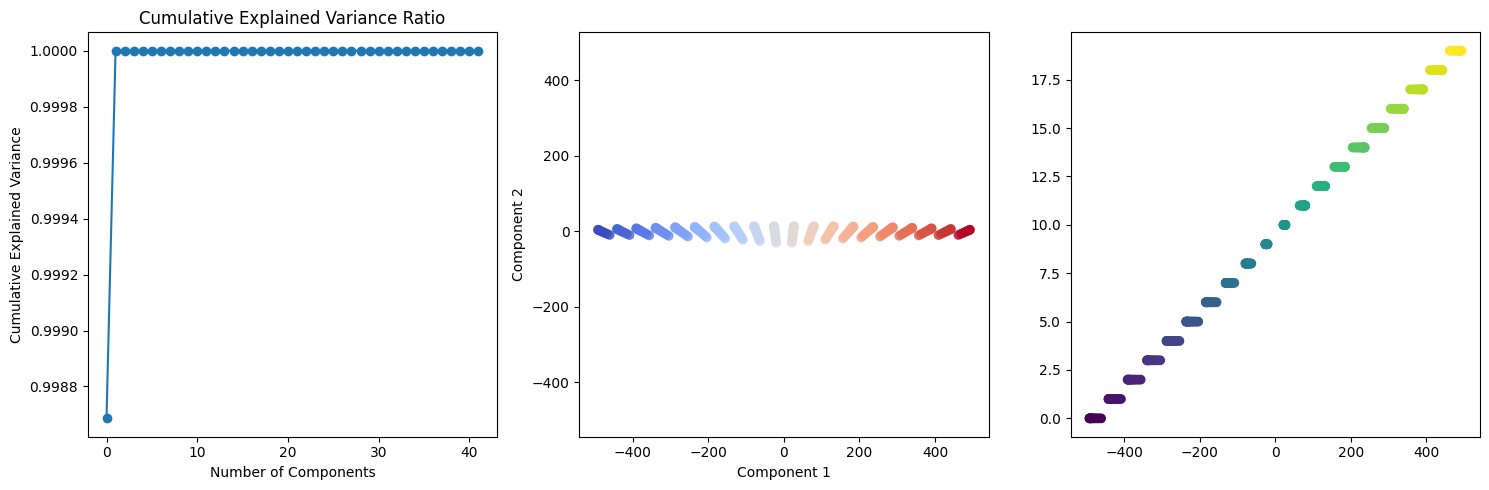

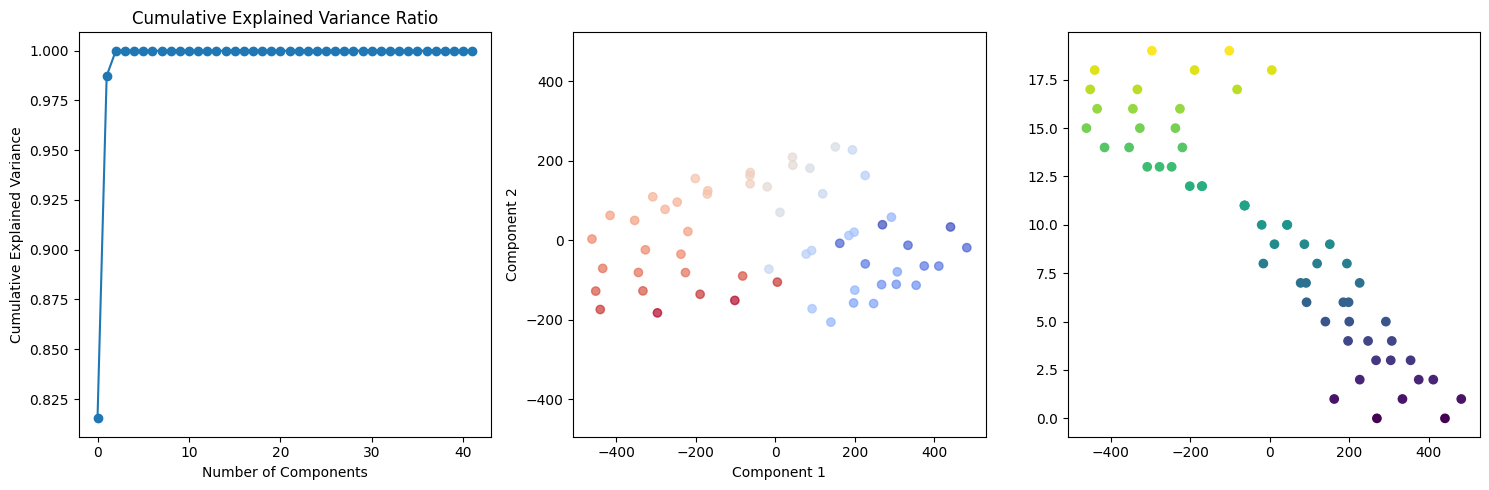

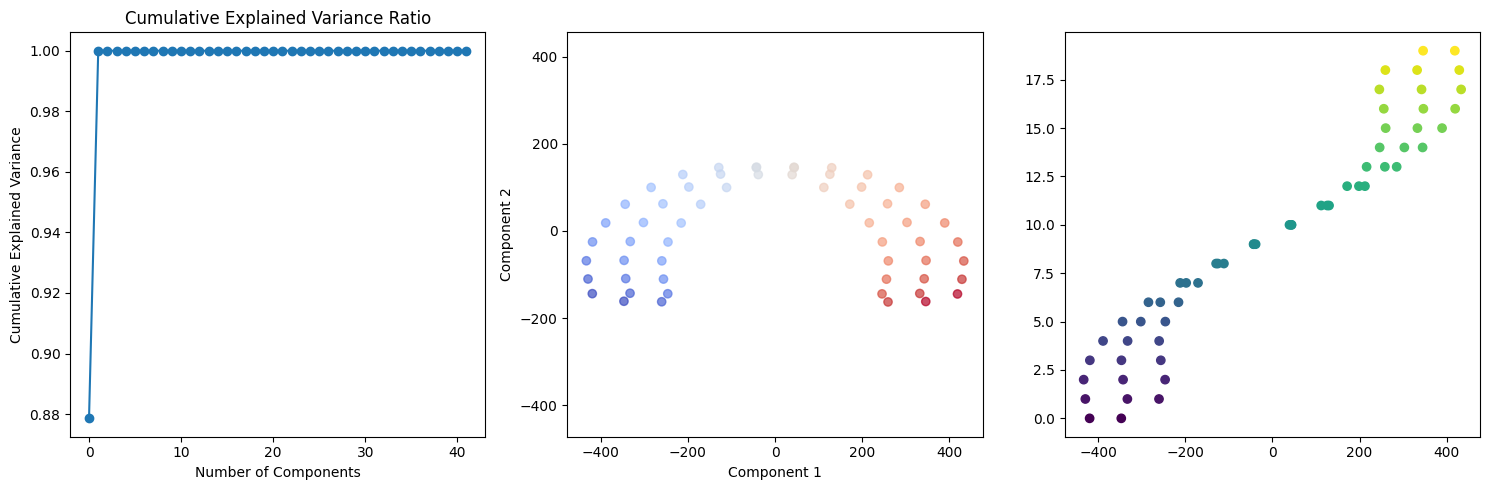

In [7]:
def plot_pca(data_dict):
    loc_y = data_dict['loc_y']; h_np = data_dict['h_np']

    # model.load_state_dict(data_dict['model_state'])
    # _, hidden = model(data_dict_l[0]['X'])
    # h_np = hidden[-1].detach().cpu().numpy()
    # loc_y = data_dict_l[0]['loc_y']
    
    pca = PCA().fit(h_np)
    X_reduced = pca.transform(h_np)
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    # Add cumulative explained variance ratio in the first row
    ax1 = axs[0]
    ax1.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
    ax1.set_xlabel('Number of Components')
    ax1.set_ylabel('Cumulative Explained Variance')
    ax1.set_title(f'Cumulative Explained Variance Ratio')

    ax1 = axs[1]
    s = ax1.scatter(X_reduced[:,0], X_reduced[:,1], c=loc_y, cmap='coolwarm', alpha=0.7)
    ax1.set_xlabel(f'Component 1')
    ax1.set_ylabel(f'Component 2'),
    ax1.axis('equal')

    ax1 = axs[2]
    ax1.scatter(X_reduced[:,0], loc_y, c=loc_y)

    plt.tight_layout()
    plt.show()

for data_dict in data_dict_l:
    plot_pca(data_dict)

In [8]:
import torch
import torch.nn.functional as F

def forward_pass(X, W_l):
    """Forward pass through a sequence of linear layers without non-linearities."""
    h = X
    for W in W_l:
        h = h @ W.T
    return h  # logits

def compute_loss(logits, y):
    return F.cross_entropy(logits, y)

def flatten_params(W_l):
    """Flatten all weight matrices into a single vector."""
    return torch.cat([w.reshape(-1) for w in W_l])

def unflatten_params(flat_params, shapes):
    """Restore list of weight matrices from a flat parameter vector."""
    W_l = []
    idx = 0
    for shape in shapes:
        numel = torch.prod(torch.tensor(shape)).item()
        W_l.append(flat_params[idx:idx+numel].reshape(shape))
        idx += numel
    return W_l

def compute_full_hessian(X, y, W_l):
    """Compute the full Hessian of the loss w.r.t. all weights in W_l."""
    shapes = [w.shape for w in W_l]
    flat_params = flatten_params(W_l).detach().clone().requires_grad_(True)

    # Reconstruct W_l from flat_params for autograd
    def loss_fn(p):
        W_reconstructed = unflatten_params(p, shapes)
        logits = forward_pass(X, W_reconstructed)
        loss = compute_loss(logits, y)
        return loss

    loss = loss_fn(flat_params)
    grad = torch.autograd.grad(loss, flat_params, create_graph=True)[0]

    H_rows = []
    for i in range(grad.numel()):
        grad2 = torch.autograd.grad(grad[i], flat_params, retain_graph=True)[0]
        H_rows.append(grad2)

    H = torch.stack(H_rows, dim=0)  # Shape: (n_params, n_params)
    return H

In [ ]:
# H_l = []
# for i, data_dict in enumerate(data_dict_l):
#     X = data_dict['X']; y = data_dict['y']; W_l = [data_dict['model_state'][k] for k in data_dict['model_state'].keys() if 'weight' in k]
#     if i == 0:
#         X = data_dict_l[1]['X']
#         y = data_dict_l[1]['y']
#     H_l.append(compute_full_hessian(X, y, W_l))
# print("Full Hessian shape:", [H.shape for H in H_l])

In [15]:
# eig_l = [torch.linalg.eig(H)[0] for H in tqdm(H_l)]

In [ ]:
# plt.plot(np.real(eig_l[0].cpu().numpy()), label='Large A')
# plt.plot(np.real(eig_l[1].cpu().numpy()), label='Small A')
# plt.plot(np.real(eig_l[2].cpu().numpy()), label='Small A + set initial')
# plt.xscale('log')
# plt.title('Eigenvalues of Hessian')
# plt.legend()

In [ ]:
for i, data_dict in enumerate(data_dict_l):
    hidden_l = data_dict['hidden_l']; loc_y = data_dict['loc_y']
    r2_l = [get_r_2(PCA(n_components=1).fit_transform(hidden[-1]), loc_y) for hidden in hidden_l]
    plt.plot(r2_l, label=['Large A', 'Small A', 'Small A + set initial'][i])
plt.title('R2 of first PC of hidden states to loc_y')
plt.legend()


In [ ]:
for i, data_dict in enumerate(data_dict_l):
    hidden_l = data_dict['hidden_l']; y_np = data_dict['y_np']
    NC1_l = [calc_NC1(hidden[-1], y_np.argmax(1)) for hidden in hidden_l]
    plt.plot(NC1_l, label=['Large A', 'Small A', 'Small A + set initial'][i])
plt.yscale('log')
plt.title('NC1 of hidden states')
plt.legend()


In [ ]:
for i, data_dict in enumerate(data_dict_l):
    hidden_l = data_dict['hidden_l']; y_np = data_dict['y_np']
    NC1_l = [calc_PR(hidden[-1]) for hidden in hidden_l]
    plt.plot(NC1_l, label=['Large A', 'Small A', 'Small A + set initial'][i])
plt.title('PR of hidden states')
plt.legend()


In [9]:
def factorize_matrix(M, N):
    D1, D2 = M.shape
    # Compute full SVD
    U, S, Vt = np.linalg.svd(M, full_matrices=False)
    rank = np.sum(S > 1e-10)  # numerical rank

    # Generate random orthogonal matrix
    Q = np.random.randn(N, N)
    Q, _ = np.linalg.qr(Q)

    S = np.diag(S)
    # Create random factorization that still reconstructs M
    S_pad = np.concatenate([S, np.zeros([D2, N-D2])], 1)
    A = U @ np.sqrt(S_pad) @ Q
    S_pad = np.concatenate([S, np.zeros([N-D2, D2])], 0)
    B = Q.T @ np.sqrt(S_pad) @ Vt
    return A, B

import numpy as np

def get_AB(X, w1, w2, b, n):
    # Step 1: Compute target matrix
    Y = (X @ w1) @ w2 + np.ones((X.shape[0], 1)) @ b  # (m, c)

    # Step 2: Compute effective Z = X^\dagger Y
    X_dagger = np.linalg.pinv(X)                     # (d, m)
    Z = X_dagger @ Y                                 # (d, c)

    # Step 3: Low-rank SVD factorization
    U, S, Vt = np.linalg.svd(Z, full_matrices=False)
    n_max = min(n, min(Z.shape))  # Don't take more components than available
    U_n = np.zeros((U.shape[0], n))  # Initialize with zeros
    S_n = np.zeros((n, n))  # Initialize diagonal matrix with zeros
    Vn = np.zeros((n, Vt.shape[1]))  # Initialize with zeros
    
    # Fill available components
    U_n[:, :n_max] = U[:, :n_max]
    S_n[:n_max, :n_max] = np.diag(np.sqrt(S[:n_max]))
    Vn[:n_max, :] = Vt[:n_max, :]

    A = U_n @ S_n                  # (d, n)
    B = S_n @ Vn                   # (n, c)
    return A, B

def find_matrices(W_target, N, L):
    W_matrices_np = []
    input_dim = W_target.shape[0]
    output_dim = W_target.shape[1]
    
    # First matrix: input dimension to N
    W_matrices_np.append(np.random.randn(input_dim, N) * np.sqrt(2.0/(input_dim + N)))
    
    # Middle matrices: N to N
    for _ in range(L-2):
        W_matrices_np.append(np.random.randn(N, N) * np.sqrt(2.0/(2*N)))
        
    # Last matrix: N to output dimension
    W_matrices_np.append(np.random.randn(N, output_dim) * np.sqrt(2.0/(N + output_dim)))
    
    # Convert to torch tensors for training
    W_matrices = [torch.tensor(W, dtype=torch.float32, requires_grad=True) for W in W_matrices_np]
    
    # Training parameters
    optimizer = torch.optim.Adam(W_matrices, lr=0.01)
    n_steps = 100000

    
    # Training loop
    for step in tqdm(range(n_steps)):
        optimizer.zero_grad()
        
        # Compute product of matrices
        W_product = W_matrices[0]
        for W in W_matrices[1:]:
            W_product = W_product @ W
            
        # Compute loss (Frobenius norm of difference)
        loss = torch.norm(W_product - torch.tensor(W_target, dtype=torch.float32))
        
        loss.backward()
        optimizer.step()
        
        # if step % (n_steps//10) == 0:
        #     print(f"Step {step}, Loss: {loss.item():.6f}")
    
    # Convert back to numpy
    W_matrices_np = [W.detach().numpy().T for W in W_matrices]

    # Verify decomposition
    W_product = W_matrices_np[0].T
    for W in W_matrices_np[1:]:
        W_product = W_product @ W.T

    print("\nDecomposition error:", np.linalg.norm(W_product - W_target))

    return W_matrices_np

def find_matrices_orthogonal(W_target, N, L):
    input_dim = W_target.shape[0]
    output_dim = W_target.shape[1]
    
    A, B = factorize_matrix(W_target, N)

    # First matrix: input dimension to N
    Q_l = [np.linalg.qr(np.random.randn(N, N))[0] for _ in range((L-2)//2)]
    Q_T_l = [Q.T for Q in Q_l]
    W_matrices_np = [A] + flatten_list([[Q, Q_T] for Q, Q_T in zip(Q_l, Q_T_l)]) + [B]
        
    W_matrices_np = [W.T for W in W_matrices_np]

    # Verify decomposition
    W_product = W_matrices_np[0].T
    for W in W_matrices_np[1:]:
        W_product = W_product @ W.T

    print("\nDecomposition error:", np.linalg.norm(W_product - W_target))

    return W_matrices_np

def calc_accuracy(X_np, y_np, W_matrices_np):
    W_effective = reduce(np.matmul, [W.T for W in W_matrices_np])
    
    return ((X_np@W_effective).argmax(1)==(y_np.argmax(1))).mean()

def normalize_W_l(W_l, norm=100):
    theta = np.concatenate([W.flatten() for W in W_l])
    factor = np.linalg.norm(theta)/norm
    return [W/factor for W in W_l]


In [10]:
import numpy as np

def compute_deep_linear_hessian(W_list, X, y):
    """
    Computes the Hessian of a deep linear neural network with cross-entropy loss
    and softmax over the outputs.

    Args:
        W_list (list of np.ndarray): A list of weight matrices for each layer.
                                     W_list[0] corresponds to W^(1), W_list[1] to W^(2), etc.
                                     Dimensions should be:
                                     - W_list[0]: (N, D_in)
                                     - W_list[l]: (N, N) for l=1 to L-2 (hidden layers)
                                     - W_list[L-1]: (D_out, N)
        X (np.ndarray): Input data. Shape (D_in, B), where D_in is input dimension
                        and B is batch size.
        y (np.ndarray): One-hot encoded target labels. Shape (D_out, B), where
                        D_out is number of output classes and B is batch size.

    Returns:
        np.ndarray: The full Hessian matrix (total_params x total_params) with
                    respect to all vectorized weight parameters. The parameters
                    are vectorized layer by layer, from W^(1) to W^(L).
    """
    L = len(W_list) # Number of layers
    D_in = W_list[0].shape[1] # Input dimension
    D_out = W_list[-1].shape[0] # Output dimension (number of classes)
    B = X.shape[1] # Batch size

    # --- Parameter Indexing Setup ---
    # Calculate total number of parameters and parameter offsets for block indexing
    # This helps in placing the computed blocks (H_Wk_Wm_c) into the full Hessian matrix.
    param_sizes = []
    current_offset = 0
    param_offsets = [] # Stores the starting index for each vectorized weight matrix
    for W in W_list:
        param_size = W.size # Number of elements in the current weight matrix
        param_sizes.append(param_size)
        param_offsets.append(current_offset)
        current_offset += param_size
    total_params = current_offset # Total number of parameters in the entire network

    # Initialize the full Hessian matrix, which will be the average over the batch
    full_hessian_batch_sum = np.zeros((total_params, total_params))

    # --- Helper Functions for P_k and Q_k ---
    # P_k = W^(k-1) * ... * W^(1)
    # This is the product of weight matrices *before* layer k.
    # In 0-indexed W_list: P_k for W_list[k_idx] is product of W_list[k_idx-1] down to W_list[0].
    def compute_Pk(k_idx):
        """
        Computes P_k = W^(k-1) * ... * W^(1).
        This means, in 0-indexed W_list, P_k for W_list[k_idx] is
        W_list[k_idx-1] @ W_list[k_idx-2] @ ... @ W_list[0].
        If k_idx is 0 (for W_list[0] which is W^(1)), P_1 = I_D_in.
        """
        if k_idx == 0:
            return np.eye(D_in)
        # Initialize with the rightmost matrix in the sequence W_list[0]
        # Then multiply by W_list[1] ... W_list[k_idx-1]
        # The product is W_list[k_idx-1] @ ... @ W_list[0]
        # So we iterate backwards and multiply on the left
        Pk_val = W_list[k_idx - 1] # Start with the leftmost matrix in the product
        for i in range(k_idx - 2, -1, -1): # Iterate backwards from W_list[k_idx-2] down to W_list[0]
            Pk_val = Pk_val @ W_list[i] # Corrected: Multiply the current product by the next matrix on the right
        return Pk_val

    # Q_k = W^(L) * ... * W^(k+1)
    # This is the product of weight matrices *after* layer k.
    # In 0-indexed W_list: Q_k for W_list[k_idx] is product of W_list[L-1] down to W_list[k_idx+1].
    def compute_Qk(k_idx):
        """
        Computes Q_k = W^(L) * ... * W^(k+1).
        This means, in 0-indexed W_list, Q_k for W_list[k_idx] is
        W_list[L-1] @ W_list[L-2] @ ... @ W_list[k_idx+1].
        If k_idx is L-1 (for W_list[L-1] which is W^(L)), Q_L = I_D_out.
        """
        if k_idx == L - 1:
            return np.eye(D_out)
        # Initialize with the leftmost matrix in the sequence W_list[L-1]
        # Then multiply by W_list[L-2] ... W_list[k_idx+1]
        # The product is W_list[L-1] @ ... @ W_list[k_idx+1]
        # So we iterate backwards and multiply on the right
        Qk_val = W_list[L - 1] # Start with the leftmost matrix in the product
        for i in range(L - 2, k_idx, -1): # Iterate backwards from W_list[L-2] down to W_list[k_idx+1]
            Qk_val = Qk_val @ W_list[i] # Corrected: Multiply the current product by the next matrix on the right
        return Qk_val

    # --- Batch Iteration ---
    for c in range(B): # Iterate over each example in the batch
        x_c = X[:, c:c+1] # Current input example (D_in, 1)
        y_c = y[:, c:c+1] # Current one-hot encoded target label (D_out, 1)

        # 1. Compute pre-softmax output 'o' for the current example
        o_c = x_c
        for W_l in W_list:
            o_c = W_l @ o_c # Accumulate matrix multiplications

        # 2. Compute softmax probabilities 'hat_y' for the current example
        # Subtract max for numerical stability to prevent overflow with np.exp
        exp_o_c = np.exp(o_c - np.max(o_c))
        hat_y_c = exp_o_c / np.sum(exp_o_c, axis=0)

        # 3. Compute H_o = diag(hat_y_c) - hat_y_c @ hat_y_c.T
        # This is the Hessian of the loss with respect to the pre-softmax outputs 'o'.
        H_o_c = np.diag(hat_y_c.flatten()) - hat_y_c @ hat_y_c.T

        # Initialize the Hessian matrix for the current example
        hessian_c = np.zeros((total_params, total_params))

        # --- Block Hessian Calculation ---
        # Iterate over all pairs of layers (k, m) to compute the blocks of the full Hessian
        # H_Wk_Wm is the block representing the second derivative with respect to W^(k) and W^(m)
        for k_idx in range(L): # 0-indexed layer index for W^(k_idx+1)
            Pk = compute_Pk(k_idx)
            Qk = compute_Qk(k_idx)

            # Compute the left term of the Kronecker product for the (k, m)-th block
            # (P_k x_c \otimes Q_k^T)
            term_left = np.kron(Pk @ x_c, Qk.T)

            for m_idx in range(L): # 0-indexed layer index for W^(m_idx+1)
                Pm = compute_Pk(m_idx)
                Qm = compute_Qk(m_idx)

                # Compute the right term of the Kronecker product for the (k, m)-th block
                # ((P_m x_c)^T \otimes Q_m)
                term_right = np.kron((Pm @ x_c).T, Qm)

                # Compute the (k, m)-th block of the Hessian for the current example
                H_Wk_Wm_c = term_left @ H_o_c @ term_right

                # Determine the slice indices for placing this block into the overall Hessian_c
                start_row = param_offsets[k_idx]
                end_row = start_row + param_sizes[k_idx]
                start_col = param_offsets[m_idx]
                end_col = start_col + param_sizes[m_idx]

                # Place the computed block into the Hessian matrix for this example
                hessian_c[start_row:end_row, start_col:end_col] = H_Wk_Wm_c

        # Accumulate the Hessian for the current example to sum over the batch
        full_hessian_batch_sum += hessian_c

    # Return the averaged Hessian over the entire batch
    return full_hessian_batch_sum / B

def compute_trace_of_deep_linear_hessian(W_list, X, y):
    """
    Computes the trace of the Hessian of a deep linear neural network with
    cross-entropy loss and softmax over the outputs.

    Args:
        W_list (list of np.ndarray): A list of weight matrices for each layer.
                                     W_list[0] corresponds to W^(1), W_list[1] to W^(2), etc.
                                     Dimensions should be:
                                     - W_list[0]: (N, D_in)
                                     - W_list[l]: (N, N) for l=1 to L-2 (hidden layers)
                                     - W_list[L-1]: (D_out, N)
        X (np.ndarray): Input data. Shape (D_in, B), where D_in is input dimension
                        and B is batch size.
        y (np.ndarray): One-hot encoded target labels. Shape (D_out, B), where
                        D_out is number of output classes and B is batch size.

    Returns:
        float: The trace of the full Hessian matrix, averaged over the batch.
    """
    L = len(W_list) # Number of layers
    D_in = W_list[0].shape[1] # Input dimension
    D_out = W_list[-1].shape[0] # Output dimension (number of classes)
    B = X.shape[1] # Batch size

    total_trace_sum = 0.0 # Accumulator for the sum of traces over all examples

    # --- Helper Functions for P_k and Q_k (reused from previous derivation) ---
    # P_k = W^(k-1) * ... * W^(1)
    # This means, in 0-indexed W_list, P_k for W_list[k_idx] is
    # W_list[k_idx-1] @ W_list[k_idx-2] @ ... @ W_list[0].
    # If k_idx is 0 (for W_list[0] which is W^(1)), P_1 = I_D_in.
    def compute_Pk(k_idx):
        if k_idx == 0:
            return np.eye(D_in)
        Pk_val = W_list[k_idx - 1]
        for i in range(k_idx - 2, -1, -1):
            Pk_val = Pk_val @ W_list[i]
        return Pk_val

    # Q_k = W^(L) * ... * W^(k+1)
    # This means, in 0-indexed W_list, Q_k for W_list[k_idx] is
    # W_list[L-1] @ W_list[L-2] @ ... @ W_list[k_idx+1].
    # If k_idx is L-1 (for W_list[L-1] which is W^(L)), Q_L = I_D_out.
    def compute_Qk(k_idx):
        if k_idx == L - 1:
            return np.eye(D_out)
        Qk_val = W_list[L - 1]
        for i in range(L - 2, k_idx, -1):
            Qk_val = Qk_val @ W_list[i]
        return Qk_val

    # --- Batch Iteration ---
    for c in range(B): # Iterate over each example in the batch
        x_c = X[:, c:c+1] # Current input example (D_in, 1)
        y_c = y[:, c:c+1] # Current one-hot encoded target label (D_out, 1)

        # 1. Compute pre-softmax output 'o' for the current example
        o_c = x_c
        for W_l in W_list:
            o_c = W_l @ o_c

        # 2. Compute softmax probabilities 'hat_y' for the current example
        exp_o_c = np.exp(o_c - np.max(o_c)) # Numerical stability
        hat_y_c = exp_o_c / np.sum(exp_o_c, axis=0)

        # --- Sum over layers (k) for the current example ---
        trace_for_example_c = 0.0
        for k_idx in range(L): # 0-indexed layer index for W^(k_idx+1)
            Pk = compute_Pk(k_idx)
            Qk = compute_Qk(k_idx)

            # Calculate ||P_k x_c||^2
            norm_Pk_xc_sq = np.sum((Pk @ x_c)**2)

            # Calculate Q_k Q_k^T
            Qk_QkT = Qk @ Qk.T

            # Calculate the first term: sum_i (Q_k Q_k^T)_ii * hat_y_ci
            sum_diag_Qk_QkT_hat_yc = np.sum(np.diag(Qk_QkT) * hat_y_c.flatten())

            # Calculate the second term: hat_y_c^T Q_k Q_k^T hat_y_c
            hat_yc_T_Qk_QkT_hat_yc = hat_y_c.T @ Qk_QkT @ hat_y_c
            # This result is a 1x1 matrix, so extract the scalar value
            hat_yc_T_Qk_QkT_hat_yc_scalar = hat_yc_T_Qk_QkT_hat_yc[0, 0]

            # Accumulate the trace component for this layer and example
            trace_for_example_c += norm_Pk_xc_sq * (sum_diag_Qk_QkT_hat_yc - hat_yc_T_Qk_QkT_hat_yc_scalar)

        # Accumulate the trace for the current example to the total batch sum
        total_trace_sum += trace_for_example_c

    # Return the averaged trace over the entire batch
    return total_trace_sum / B

In [85]:
trace_H_SGD_l = []
trace_H_logistic_l = []
eigs_SGD_l = []
W_SGD_l = []
eigs_logistic_l = []
W_logistic_l = []

for data_dict in data_dict_l:
    X_np = data_dict['X_np']; y_np = data_dict['y_np']
    X = data_dict['X']; y = data_dict['y']
    W_logistic = LogisticRegression(multi_class='multinomial', penalty=None, fit_intercept=False, tol=1e-12).fit(X_np, y_np.argmax(1)).coef_.T

    L = C.length_corridors[0]
    L_start = -L/2; L_end = L/2
    A = C.max_move
    n_model = 1
    Win = np.concatenate([np.linspace(L_start,L_end, L), np.linspace(-A,A, 2*A+1)])[:,None]
    Wout = 1/n_model*np.linspace(L_start,L_end, L)[None,:]**n_model
    b = -1/(n_model+1)*np.linspace(L_start,L_end, L)[None, :]**(n_model+1)

    A,B = get_AB(X_np, Win, Wout, b, C.hidden_size)
    W_synthetic = (A@B)
    print('Accuracy of tailored solution: ', ((X_np@A@B).argmax(1)==(y_np.argmax(1))).mean())

    # Decompose W_logistic into L matrices with intermediate dimension N
    L = C.L+1  # Number of layers
    N = C.hidden_size  # Intermediate dimension

    # Initialize matrices with Xavier initialization
    W_matrices_logistic_np = normalize_W_l(find_matrices_orthogonal(W_logistic, C.hidden_size, C.L+1))
    W_matrices_synthetic_np = normalize_W_l(find_matrices_orthogonal(W_synthetic, C.hidden_size, C.L+1))

    print('Accuracy of logistic solution: ', calc_accuracy(X_np, y_np, W_matrices_logistic_np))
    print('Accuracy of synthetic solution: ', calc_accuracy(X_np, y_np, W_matrices_synthetic_np))
    W_l = W_matrices_logistic_np
    # H = compute_full_hessian(X, y, W_l)
    # eigs_logistic_l.append(torch.linalg.eig(H)[0])
    trace_H_SGD_l.append(compute_trace_of_deep_linear_hessian(W_l, X_np.T, y_np.T))
    W_logistic_l.append(W_l)

    W_l = W_matrices_synthetic_np
    # H = compute_full_hessian(X, y, W_l)
    # eigs_SGD_l.append(torch.linalg.eig(H)[0])
    trace_H_logistic_l.append(compute_trace_of_deep_linear_hessian(W_l, X_np.T, y_np.T))
    W_SGD_l.append(W_l)
    
    W_l = [W.detach().numpy() for W in data_dict['model_state'].values()]
    data_dict['W_l'] = W_l
    data_dict['H'] = compute_deep_linear_hessian(W_l, X_np.T, y_np.T)

with open('data_dict_l.pkl', 'wb') as f:
    pkl.dump(data_dict_l, f)

c:\Users\avivra\Desktop\cursor_projects\RepresentationShaping\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy of tailored solution:  0.964516129032258

Decomposition error: 7.688859769970812e-10

Decomposition error: 6.82169030656344e-13
Accuracy of logistic solution:  1.0
Accuracy of synthetic solution:  0.964516129032258


c:\Users\avivra\Desktop\cursor_projects\RepresentationShaping\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy of tailored solution:  1.0

Decomposition error: 5.915000584674676e-11

Decomposition error: 4.494628654353769e-13
Accuracy of logistic solution:  1.0
Accuracy of synthetic solution:  1.0


c:\Users\avivra\Desktop\cursor_projects\RepresentationShaping\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy of tailored solution:  1.0

Decomposition error: 5.933555851561966e-11

Decomposition error: 3.2729354111671044e-13
Accuracy of logistic solution:  1.0
Accuracy of synthetic solution:  1.0


In [83]:
exp_types = ['Large A', 'Small A', 'Small A + set initial']
for i, trace in enumerate(trace_H_SGD_l):
    print(f'Synthetic W with {exp_types[i]}: {trace}')

for i, trace in enumerate(trace_H_logistic_l):
    print(f'Logistic W with {exp_types[i]}: {trace}')



Synthetic W with Large A: 7.050827687834801
Synthetic W with Small A: 1125.4800482395385
Synthetic W with Small A + set initial: 1125.4800482395392
Logistic W with Large A: 7984.294757998984
Logistic W with Small A: 0.0
Logistic W with Small A + set initial: 0.0


In [18]:
for data_dict in data_dict_l:
    H = data_dict['H']
    X_np = data_dict['X_np']
    y_np = data_dict['y_np']
    W_l = data_dict['W_l']
    trace_H = np.trace(H)
    print(trace_H, compute_trace_of_deep_linear_hessian(W_l, X_np.T, y_np.T))

40.79041135444343 40.77118849840235
18.09343615525296 18.091453333178983
19.769112394564743 19.769078056995195


In [28]:
L = C.length_corridors[0]
L_start = -L/2; L_end = L/2
A = C.max_move
n_model = 1
Win = np.concatenate([np.linspace(L_start,L_end, L), np.linspace(-A,A, 2*A+1)])[:,None]
Wout = 1/n_model*np.linspace(L_start,L_end, L)[None,:]**n_model
b = -1/(n_model+1)*np.linspace(L_start,L_end, L)[None, :]**(n_model+1)

A,B = get_AB(X_np, Win, Wout, b, C.hidden_size)
W_synthetic = (A@B)
print('Accuracy of tailored solution: ', ((X_np@A@B).argmax(1)==(y_np.argmax(1))).mean())

# Decompose W_logistic into L matrices with intermediate dimension N
L = C.L+1  # Number of layers
N = C.hidden_size  # Intermediate dimension

# Initialize matrices with Xavier initialization
W_l = find_matrices_orthogonal(W_synthetic, C.hidden_size, C.L+1)
W_l = data_dict['W_l']
trace_l = [compute_trace_of_deep_linear_hessian(normalize_W_l(W_l, n), X_np.T, y_np.T) for n in np.arange(1, 100)]

Accuracy of tailored solution:  1.0

Decomposition error: 4.612498975724315e-13


In [27]:

theta = np.concatenate([W.flatten() for W in data_dict['W_l']])
np.linalg.norm(theta)

15.337803

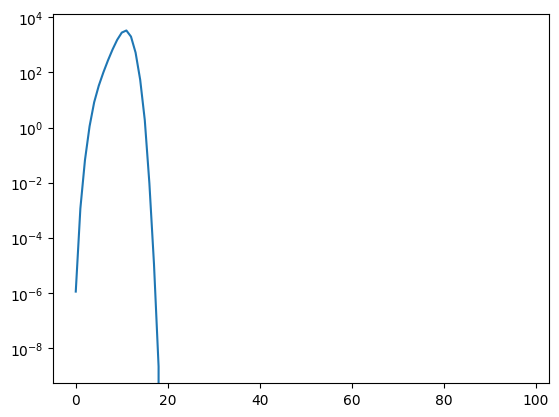

In [29]:
plt.plot(trace_l)
plt.yscale('log')
plt.show()

In [16]:
W_l = [W.detach().numpy() for W in data_dict_l[0]['model_state'].values()]
X_np = data_dict_l[0]['X_np']
y_np = data_dict_l[0]['y_np']

H = compute_deep_linear_hessian(W_l, X_np.T, y_np.T)

# eigs = torch.linalg.eig(H)[0]
# eigs_real = torch.real(eigs)
# eigs_imag = torch.imag(eigs)

# plt.plot(abs(eigs_real))
# plt.plot(abs(eigs_imag))
# plt.show()

In [19]:
X = data_dict_l[0]['X']
y = data_dict_l[0]['y']
H_numeric = compute_full_hessian(X, y, [torch.tensor(W, dtype=torch.float32) for W in W_l]).detach().numpy()

In [26]:
print(np.trace(H))
print(np.trace(H_numeric))
print(compute_trace_of_deep_linear_hessian(W_l, X_np.T, y_np.T))

40.79041135444343
40.784546
40.77118849840235


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

ax1.plot(abs(np.real(eigs_SGD_l[0].cpu().numpy())), label='Large A')
ax1.plot(abs(np.real(eigs_SGD_l[1].cpu().numpy())), label='Small A')
ax1.plot(abs(np.real(eigs_SGD_l[2].cpu().numpy())), label='Small A + set initial')
ax1.set_xscale('log'); ax1.set_yscale('log')
ax1.set_title('Eigenvalues of Hessian (SGD)')
ax1.legend()

ax2.plot(abs(np.real(eigs_logistic_l[0].cpu().numpy())), label='Large A')
ax2.plot(abs(np.real(eigs_logistic_l[1].cpu().numpy())), label='Small A')
ax2.plot(abs(np.real(eigs_logistic_l[2].cpu().numpy())), label='Small A + set initial')
ax2.set_xscale('log'); ax2.set_yscale('log')
ax2.set_title('Eigenvalues of Hessian (Logistic)')
ax2.legend()

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

# Plot norms of decomposed matrices
[ax1.plot([np.linalg.norm(W) for W in W_l], 'o-', label='Decomposed matrices') for W_l in W_logistic_l]
ax1.set_title('Norms of decomposed logistic matrices')
ax1.set_xlabel('Matrix index')
ax1.set_ylabel('Frobenius norm')
ax1.legend()

# Plot norms of SGD matrices
[ax2.plot([np.linalg.norm(W) for W in W_l], 'o-', label='Decomposed matrices') for W_l in W_SGD_l]
ax2.set_title('Norms of decomposed SGD matrices')
ax2.set_xlabel('Matrix index')
ax2.set_ylabel('Frobenius norm')
ax2.legend()

plt.tight_layout()
